# CWRU Color Spectrogram Model Training & Report Figures

이 노트북은 컬러 스펙트로그램 데이터셋을 학습하고, 보고서에 넣을 수 있는 비교 피규어를 자동으로 저장하는 파일이다.

포함 모델:

- SmallSpectroCNN
- ResNet18 from scratch
- ResNet18 fine-tuning
- MobileNetV3-Small
- EfficientNet-B0

생성 결과:

- validation accuracy/loss 수렴 곡선
- test accuracy 비교 그래프
- epoch당 학습 시간 비교 그래프
- 모델별 confusion matrix
- 최고 성능 모델 Grad-CAM 예시


In [1]:
"""
CWRU color spectrogram classification training script.

Recommended workflow:
1. Run 02_make_training_dataset_sliding_COLOR.ipynb first.
2. Check that this folder exists:
   ./cwru_spectrogram_training_dataset/split_dataset/train
3. Run this script.

This script trains and compares:
- SmallSpectroCNN
- ResNet18 from scratch
- ResNet18 fine-tuning (ImageNet weights if available)
- MobileNetV3-Small
- EfficientNet-B0

Outputs:
- trained_models/*.pth
- reports/history_all.csv
- reports/model_comparison.csv
- reports/*.png report figures
"""

from __future__ import annotations

import json
import random
import time
import copy
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision import datasets, models

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x




In [2]:
# =========================
# User settings


In [3]:
# =========================
DATASET_ROOT = Path("./cwru_spectrogram_training_dataset/split_dataset")
OUTPUT_DIR = Path("./cwru_model_comparison_results")
MODEL_DIR = OUTPUT_DIR / "trained_models"
REPORT_DIR = OUTPUT_DIR / "reports"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 6
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 0  # Windows에서는 0이 가장 안전하다.

# 빠른 테스트는 아래 리스트를 줄이면 된다.
MODEL_NAMES = [
    "small_cnn",
    "resnet18_scratch",
    "resnet18_finetune",
    "mobilenet_v3_small",
    "efficientnet_b0",
]

# True이면 torchvision의 ImageNet pretrained weight를 사용하려고 시도한다.
# 인터넷/캐시 문제로 실패하면 자동으로 random init으로 fallback한다.
USE_PRETRAINED_IF_AVAILABLE = True



In [4]:
# =========================
# Reproducibility


In [5]:
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False




In [6]:
# =========================
# Model definitions


In [7]:
# =========================
class SmallSpectroCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def _safe_weights(weights_enum):
    if not USE_PRETRAINED_IF_AVAILABLE:
        return None
    try:
        return weights_enum.DEFAULT
    except Exception:
        return None


def build_model(name: str, num_classes: int) -> nn.Module:
    name = name.lower()

    if name == "small_cnn":
        return SmallSpectroCNN(num_classes)

    if name == "resnet18_scratch":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if name == "resnet18_finetune":
        try:
            weights = _safe_weights(models.ResNet18_Weights)
            model = models.resnet18(weights=weights)
        except Exception:
            model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if name == "mobilenet_v3_small":
        try:
            weights = _safe_weights(models.MobileNet_V3_Small_Weights)
            model = models.mobilenet_v3_small(weights=weights)
        except Exception:
            model = models.mobilenet_v3_small(weights=None)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    if name == "efficientnet_b0":
        try:
            weights = _safe_weights(models.EfficientNet_B0_Weights)
            model = models.efficientnet_b0(weights=weights)
        except Exception:
            model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unknown model name: {name}")


def get_target_layer(model: nn.Module, model_name: str):
    if model_name == "small_cnn":
        return model.features[-2]  # last ReLU before GAP
    if model_name.startswith("resnet18"):
        return model.layer4[-1]
    if model_name == "mobilenet_v3_small":
        return model.features[-1]
    if model_name == "efficientnet_b0":
        return model.features[-1]
    return None




In [8]:
# =========================
# Data


In [9]:
# =========================
def build_dataloaders(dataset_root: Path):
    train_tf = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15)], p=0.3),
        T.RandomAffine(degrees=3, translate=(0.02, 0.02)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    eval_tf = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    train_ds = datasets.ImageFolder(dataset_root / "train", transform=train_tf)
    val_ds = datasets.ImageFolder(dataset_root / "val", transform=eval_tf)
    test_ds = datasets.ImageFolder(dataset_root / "test", transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    return train_loader, val_loader, test_loader, train_ds.classes




In [10]:
# =========================
# Training and evaluation


In [11]:
# =========================
def run_one_epoch(model, loader, criterion, optimizer, device, train: bool):
    model.train(train)
    losses, ys, preds = [], [], []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()

        losses.append(loss.item() * images.size(0))
        ys.extend(labels.detach().cpu().numpy().tolist())
        preds.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())

    avg_loss = float(np.sum(losses) / len(loader.dataset))
    acc = accuracy_score(ys, preds)
    macro_f1 = f1_score(ys, preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1


@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, preds = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        ys.extend(labels.numpy().tolist())
        preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    return np.array(ys), np.array(preds)


def train_model(model_name: str, train_loader, val_loader, test_loader, class_names, device):
    num_classes = len(class_names)
    model = build_model(model_name, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_state = None
    best_val_acc = -1.0
    history = []
    start_time = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, train_f1 = run_one_epoch(model, train_loader, criterion, optimizer, device, train=True)
        val_loss, val_acc, val_f1 = run_one_epoch(model, val_loader, criterion, optimizer, device, train=False)
        scheduler.step()

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_macro_f1": val_f1,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(f"[{model_name}] epoch {epoch:03d}/{NUM_EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start_time
    if best_state is not None:
        model.load_state_dict(best_state)

    y_test, p_test = predict_all(model, test_loader, device)
    test_acc = accuracy_score(y_test, p_test)
    test_f1 = f1_score(y_test, p_test, average="macro", zero_division=0)

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_name": model_name,
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
        "test_acc": test_acc,
        "test_macro_f1": test_f1,
    }, MODEL_DIR / f"{model_name}.pth")

    summary = {
        "model": model_name,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_macro_f1": test_f1,
        "train_time_sec": elapsed,
        "sec_per_epoch": elapsed / NUM_EPOCHS,
        "num_epochs": NUM_EPOCHS,
    }
    return model, pd.DataFrame(history), summary, y_test, p_test




In [12]:
# =========================
# Figures


In [13]:
# =========================
def save_curve_figures(history_df: pd.DataFrame):
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(9, 5))
    for model_name, g in history_df.groupby("model"):
        plt.plot(g["epoch"], g["val_acc"], marker="o", label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy Convergence")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "fig_val_accuracy_convergence.png", dpi=200)
    plt.close()

    plt.figure(figsize=(9, 5))
    for model_name, g in history_df.groupby("model"):
        plt.plot(g["epoch"], g["val_loss"], marker="o", label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Convergence")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "fig_val_loss_convergence.png", dpi=200)
    plt.close()


def save_comparison_figures(summary_df: pd.DataFrame):
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    x = np.arange(len(summary_df))
    labels = summary_df["model"].tolist()

    plt.figure(figsize=(10, 5))
    plt.bar(x, summary_df["test_acc"])
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel("Test Accuracy")
    plt.title("Final Test Accuracy Comparison")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "fig_test_accuracy_comparison.png", dpi=200)
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.bar(x, summary_df["sec_per_epoch"])
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel("Seconds per Epoch")
    plt.title("Training Speed Comparison")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "fig_training_speed_comparison.png", dpi=200)
    plt.close()


def save_confusion_matrix_figure(y_true, y_pred, class_names, model_name: str):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_norm, aspect="auto")
    plt.title(f"Normalized Confusion Matrix - {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar(label="Normalized count")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"fig_confusion_matrix_{model_name}.png", dpi=200)
    plt.close()




In [20]:
# =========================
# Grad-CAM


In [15]:
# =========================
def denormalize_image(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def make_gradcam(model, model_name, dataset, device, save_name="fig_gradcam_best_model.png"):
    target_layer = get_target_layer(model, model_name)
    if target_layer is None:
        return

    model.eval()
    image, label = dataset[0]
    input_tensor = image.unsqueeze(0).to(device)

    activations = {}
    gradients = {}

    def fwd_hook(module, inp, out):
        activations["value"] = out.detach()

    def bwd_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(input_tensor)
    pred = logits.argmax(dim=1).item()
    score = logits[0, pred]
    model.zero_grad(set_to_none=True)
    score.backward()

    acts = activations["value"]
    grads = gradients["value"]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze(0)
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = torch.nn.functional.interpolate(cam[None, None], size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()

    img = denormalize_image(image)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(cam, alpha=0.45)
    plt.axis("off")
    plt.title(f"Grad-CAM: {model_name}\ntrue={dataset.classes[label]}, pred={dataset.classes[pred]}")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / save_name, dpi=200)
    plt.close()

    h1.remove()
    h2.remove()




In [16]:
# =========================
# Main


In [17]:
# =========================
def main():
    set_seed(SEED)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    if not (DATASET_ROOT / "train").exists():
        raise FileNotFoundError(
            f"{DATASET_ROOT / 'train'} 폴더가 없다. 먼저 컬러 스펙트로그램 데이터셋 생성 노트북을 실행해야 한다."
        )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_loader, val_loader, test_loader, class_names = build_dataloaders(DATASET_ROOT)
    with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
        json.dump(class_names, f, ensure_ascii=False, indent=2)

    all_histories = []
    summaries = []
    preds_by_model = {}
    trained_models = {}

    for model_name in MODEL_NAMES:
        model, hist_df, summary, y_test, p_test = train_model(
            model_name, train_loader, val_loader, test_loader, class_names, device
        )
        all_histories.append(hist_df)
        summaries.append(summary)
        preds_by_model[model_name] = (y_test, p_test)
        trained_models[model_name] = model
        save_confusion_matrix_figure(y_test, p_test, class_names, model_name)

    history_df = pd.concat(all_histories, ignore_index=True)
    summary_df = pd.DataFrame(summaries).sort_values("test_acc", ascending=False).reset_index(drop=True)

    history_df.to_csv(REPORT_DIR / "history_all.csv", index=False, encoding="utf-8-sig")
    summary_df.to_csv(REPORT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")

    save_curve_figures(history_df)
    save_comparison_figures(summary_df)

    # Grad-CAM은 test accuracy 기준 최고 모델 하나만 생성한다.
    best_name = summary_df.loc[0, "model"]
    _, _, test_loader_for_cam, _ = build_dataloaders(DATASET_ROOT)
    test_dataset = test_loader_for_cam.dataset
    make_gradcam(trained_models[best_name], best_name, test_dataset, device)

    print("\n=== Model comparison ===")
    print(summary_df)
    print(f"\nSaved reports to: {REPORT_DIR}")




## 실행
아래 셀을 실행하면 설정된 모든 모델을 학습하고 결과 피규어를 저장한다.


In [18]:
main()


Device: cuda


  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

[small_cnn] epoch 001/6 | train_acc=0.6060 | val_acc=0.5352 | val_f1=0.4877


  0%|          | 0/52 [00:00<?, ?it/s]

...

[efficientnet_b0] epoch 005/6 | train_acc=0.9976 | val_acc=1.0000 | val_f1=1.0000


  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

[efficientnet_b0] epoch 006/6 | train_acc=1.0000 | val_acc=1.0000 | val_f1=1.0000


RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

In [19]:
# ============================================================
# Test evaluation + inference speed benchmark + report figures
# 이 셀은 main() 학습이 끝난 뒤 실행하면 된다.
# 이미 저장된 trained_models/*.pth 파일을 다시 불러와서 평가한다.
# ============================================================

import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -------------------------
# 1. 경로 설정
# -------------------------
DATASET_ROOT = Path("./cwru_spectrogram_training_dataset/split_dataset")
OUTPUT_DIR = Path("./cwru_model_comparison_results")
MODEL_DIR = OUTPUT_DIR / "trained_models"
REPORT_DIR = OUTPUT_DIR / "reports"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 2. 장치 설정
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------
# 3. 테스트 데이터로더
# -------------------------
eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

test_ds = datasets.ImageFolder(DATASET_ROOT / "test", transform=eval_tf)
test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if device.type == "cuda" else False
)

class_names = test_ds.classes
num_classes = len(class_names)

print("Number of test images:", len(test_ds))
print("Classes:", class_names)

# -------------------------
# 4. 모델 파라미터 수 계산 함수
# -------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

# -------------------------
# 5. 저장된 모델 불러오기
# -------------------------
def load_saved_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)

    model_name = checkpoint["model_name"]
    class_names_ckpt = checkpoint["class_names"]

    model = build_model(model_name, len(class_names_ckpt))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return model, model_name, class_names_ckpt

# -------------------------
# 6. 테스트셋 전체 예측
# -------------------------
@torch.no_grad()
def evaluate_on_test(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return y_true, y_pred, y_prob, acc, macro_f1, weighted_f1

# -------------------------
# 7. 추론 속도 측정
# -------------------------
@torch.no_grad()
def benchmark_inference_speed(model, loader, device, warmup_batches=5):
    """
    forward-only 기준 추론 속도 측정.
    DataLoader에서 이미지를 가져오는 시간은 최대한 제외하고,
    모델 forward 시간 중심으로 측정한다.
    """
    model.eval()

    # 첫 번째 batch 하나 가져오기
    images, _ = next(iter(loader))
    images = images.to(device, non_blocking=True)

    # warm-up
    for _ in range(warmup_batches):
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()

    # 전체 test_loader를 한 바퀴 돌면서 forward 시간 측정
    total_images = 0
    total_time = 0.0

    for images, _ in loader:
        images = images.to(device, non_blocking=True)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

        batch_time = end - start
        total_time += batch_time
        total_images += images.size(0)

    images_per_sec = total_images / total_time
    ms_per_image = (total_time / total_images) * 1000.0

    return {
        "total_images": total_images,
        "forward_time_sec": total_time,
        "images_per_sec": images_per_sec,
        "ms_per_image": ms_per_image,
    }

# -------------------------
# 8. confusion matrix 저장
# -------------------------
def save_confusion_matrix(y_true, y_pred, class_names, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_norm, aspect="auto")
    plt.title(f"Normalized Confusion Matrix - {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar(label="Normalized count")
    plt.tight_layout()

    save_path = REPORT_DIR / f"fig_test_confusion_matrix_{model_name}.png"
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved:", save_path)

# -------------------------
# 9. 저장된 모든 모델 평가
# -------------------------
model_paths = sorted(MODEL_DIR.glob("*.pth"))

if len(model_paths) == 0:
    raise FileNotFoundError(
        f"{MODEL_DIR} 안에 .pth 모델 파일이 없다. 먼저 main()을 실행해서 모델을 학습/저장해야 한다."
    )

all_results = {}
rows = []

for model_path in model_paths:
    print("\n" + "=" * 70)
    print("Loading:", model_path.name)

    model, model_name, ckpt_class_names = load_saved_model(model_path, device)

    y_true, y_pred, y_prob, acc, macro_f1, weighted_f1 = evaluate_on_test(
        model, test_loader, device
    )

    speed = benchmark_inference_speed(
        model, test_loader, device, warmup_batches=5
    )

    num_params = count_parameters(model)

    row = {
        "model": model_name,
        "test_acc": acc,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "num_params": num_params,
        "num_params_M": num_params / 1e6,
        "images_per_sec": speed["images_per_sec"],
        "ms_per_image": speed["ms_per_image"],
        "forward_time_sec": speed["forward_time_sec"],
        "total_test_images": speed["total_images"],
        "device": str(device),
    }

    rows.append(row)

    all_results[model_name] = {
        "model": model,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "row": row,
    }

    print(f"Model: {model_name}")
    print(f"Test Accuracy   : {acc:.4f}")
    print(f"Test Macro F1   : {macro_f1:.4f}")
    print(f"Weighted F1     : {weighted_f1:.4f}")
    print(f"Params          : {num_params / 1e6:.2f} M")
    print(f"Inference Speed : {speed['images_per_sec']:.2f} images/sec")
    print(f"Latency         : {speed['ms_per_image']:.4f} ms/image")

# -------------------------
# 10. 결과 CSV 저장
# -------------------------
result_df = pd.DataFrame(rows)
result_df = result_df.sort_values("test_acc", ascending=False).reset_index(drop=True)

csv_path = REPORT_DIR / "test_and_inference_speed_results.csv"
result_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("\n" + "=" * 70)
print("Final result table")
display(result_df)
print("Saved:", csv_path)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Number of test images: 355
Classes: ['Fault_BALL_007', 'Fault_BALL_014', 'Fault_BALL_021', 'Fault_IR_007', 'Fault_IR_014', 'Fault_IR_021', 'Fault_OR_007', 'Fault_OR_014', 'Fault_OR_021', 'Normal']

Loading: efficientnet_b0.pth


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_4760\1363758510.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

Model: efficientnet_b0
Test Accuracy   : 0.9972
Test Macro F1   : 0.9972
Weighted F1     : 0.9972
Params          : 4.02 M
Inference Speed : 1306.38 images/sec
Latency         : 0.7655 ms/image

Loading: mobilenet_v3_small.pth


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_4760\1363758510.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

Model: mobilenet_v3_small
Test Accuracy   : 1.0000
Test Macro F1   : 1.0000
Weighted F1     : 1.0000
Params          : 1.53 M
Inference Speed : 4683.33 images/sec
Latency         : 0.2135 ms/image

Loading: resnet18_finetune.pth


...

Model: resnet18_scratch
Test Accuracy   : 0.9944
Test Macro F1   : 0.9943
Weighted F1     : 0.9944
Params          : 11.18 M
Inference Speed : 1745.21 images/sec
Latency         : 0.5730 ms/image

Loading: small_cnn.pth


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_4760\1363758510.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

Model: small_cnn
Test Accuracy   : 1.0000
Test Macro F1   : 1.0000
Weighted F1     : 1.0000
Params          : 0.39 M
Inference Speed : 1716.35 images/sec
Latency         : 0.5826 ms/image

Final result table


,model,test_acc,test_macro_f1,test_weighted_f1,num_params,num_params_M,images_per_sec,ms_per_image,forward_time_sec,total_test_images,device
0,mobilenet_v3_small,1.000000,1.000000,1.000000,1528106,1.528106,4683.327882,0.213523,0.075801,355,cuda
1,small_cnn,1.000000,1.000000,1.000000,391946,0.391946,1716.348094,0.582632,0.206835,355,cuda
2,resnet18_finetune,1.000000,1.000000,1.000000,11181642,11.181642,1534.158581,0.651823,0.231397,355,cuda
3,efficientnet_b0,0.997183,0.997181,0.997182,4020358,4.020358,1306.378993,0.765475,0.271744,355,cuda
4,resnet18_scratch,0.994366,0.994325,0.994366,11181642,11.181642,1745.213568,0.572996,0.203413,355,cuda


Saved: cwru_model_comparison_results\reports\test_and_inference_speed_results.csv


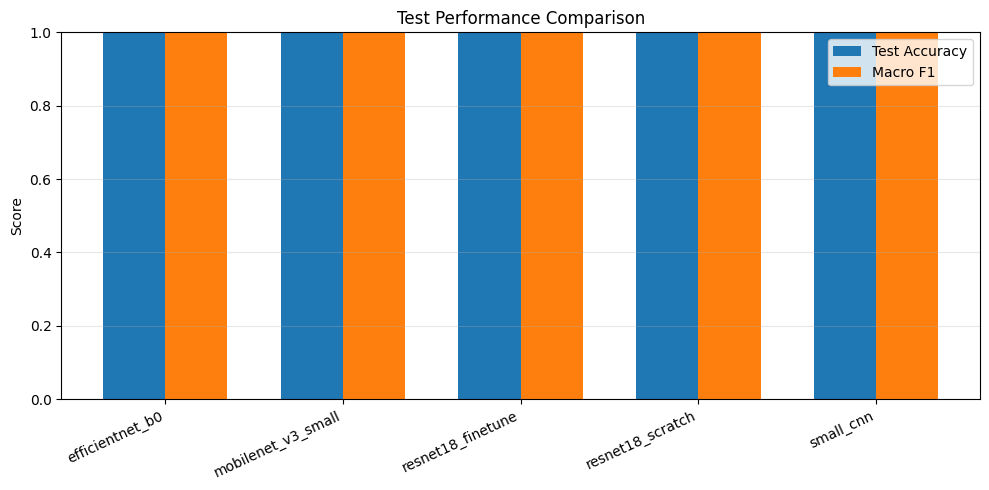

Saved: cwru_model_comparison_results\reports\fig_test_accuracy_macro_f1_comparison.png


In [ ]:
# ============================================================
# Figure 1. Test Accuracy / Macro F1 비교
# ============================================================

plot_df = result_df.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["test_acc"], width, label="Test Accuracy")
plt.bar(x + width/2, plot_df["test_macro_f1"], width, label="Macro F1")

plt.xticks(x, plot_df["model"], rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Test Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = REPORT_DIR / "fig_test_accuracy_macro_f1_comparison.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)